# Sales Performance Analysis Dashboard — EDA
Exploratory analysis of a cleaned Superstore-style sales dataset (9,800 rows) using **Pandas**, **NumPy**, **Matplotlib** and **Seaborn**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/sales_data_cleaned.csv")
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y")
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Order Year,Order Month,Order Month Name,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,7


## 1. Dataset Overview

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Row ID            9800 non-null   int64         
 1   Order ID          9800 non-null   str           
 2   Order Date        9800 non-null   datetime64[us]
 3   Ship Date         9800 non-null   datetime64[us]
 4   Ship Mode         9800 non-null   str           
 5   Customer ID       9800 non-null   str           
 6   Customer Name     9800 non-null   str           
 7   Segment           9800 non-null   str           
 8   Country           9800 non-null   str           
 9   City              9800 non-null   str           
 10  State             9800 non-null   str           
 11  Postal Code       9800 non-null   int64         
 12  Region            9800 non-null   str           
 13  Product ID        9800 non-null   str           
 14  Category          9800 non-null   s

In [3]:
df.isnull().sum().sum()  # confirms 0 missing values after Excel cleaning stage

np.int64(0)

In [4]:
df["Sales"].describe()

count     9800.000000
mean       230.769059
std        626.651875
min          0.444000
25%         17.248000
50%         54.490000
75%        210.605000
max      22638.480000
Name: Sales, dtype: float64

## 2. Monthly Sales Trend

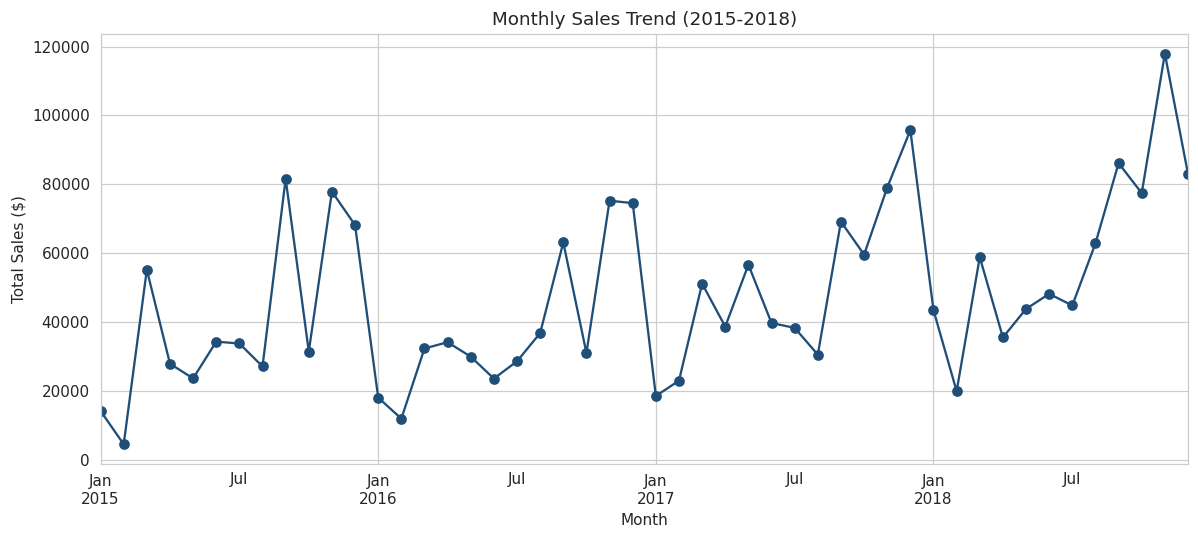

In [5]:
monthly = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()
plt.figure(figsize=(11,5))
monthly.plot(kind="line", marker="o", color="#1F4E78")
plt.title("Monthly Sales Trend (2015-2018)")
plt.ylabel("Total Sales ($)")
plt.xlabel("Month")
plt.tight_layout()
plt.show()

## 3. Yearly Sales & YoY Growth

In [6]:
yearly = df.groupby(df["Order Date"].dt.year)["Sales"].sum()
yoy = yearly.pct_change() * 100
print(yearly)
print(yoy)

Order Date
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64
Order Date
2015          NaN
2016    -4.255484
2017    30.636812
2018    20.303396
Name: Sales, dtype: float64


## 4. Sales by Region

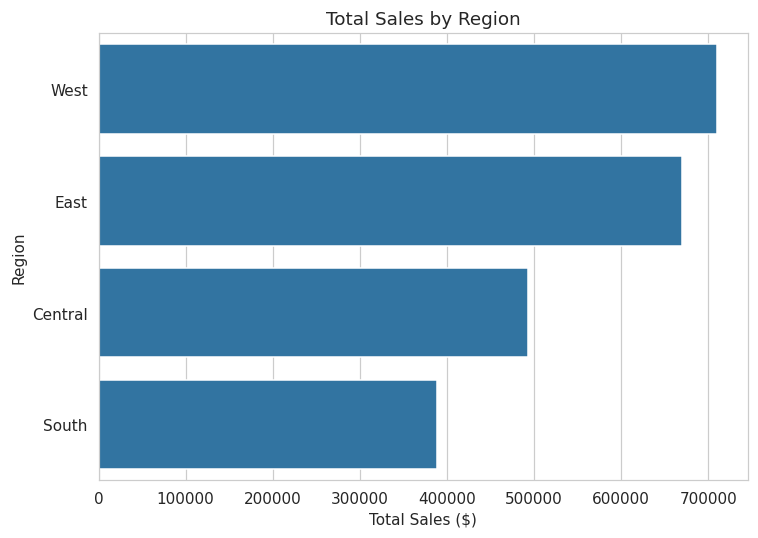

In [7]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(7,5))
sns.barplot(x=region_sales.values, y=region_sales.index)
plt.title("Total Sales by Region")
plt.xlabel("Total Sales ($)")
plt.tight_layout()
plt.show()

## 5. Sales by Category & Sub-Category

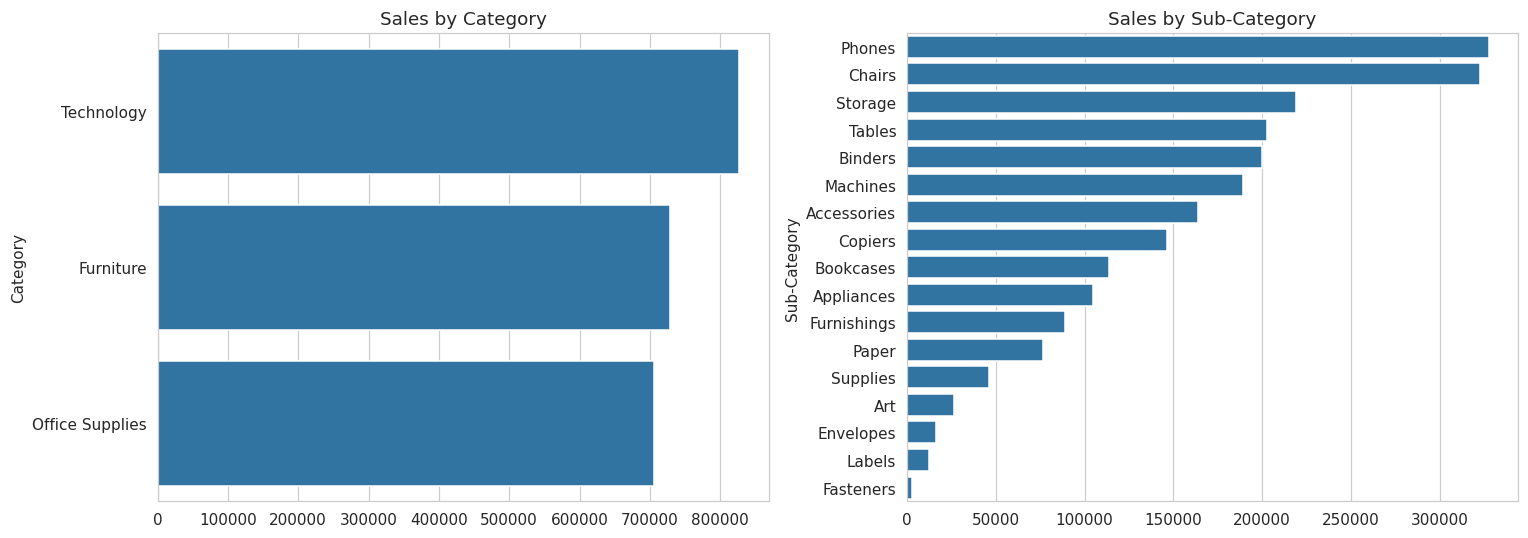

In [8]:
cat_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
subcat_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)
fig, axes = plt.subplots(1,2, figsize=(14,5))
sns.barplot(x=cat_sales.values, y=cat_sales.index, ax=axes[0])
axes[0].set_title("Sales by Category")
sns.barplot(x=subcat_sales.values, y=subcat_sales.index, ax=axes[1])
axes[1].set_title("Sales by Sub-Category")
plt.tight_layout()
plt.show()

## 6. Customer Segment Analysis

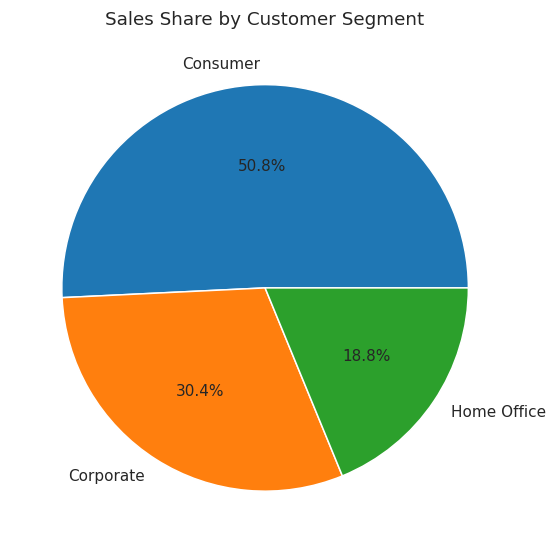

In [9]:
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(6,6))
plt.pie(segment_sales, labels=segment_sales.index, autopct="%1.1f%%")
plt.title("Sales Share by Customer Segment")
plt.show()

## 7. Top 10 Products

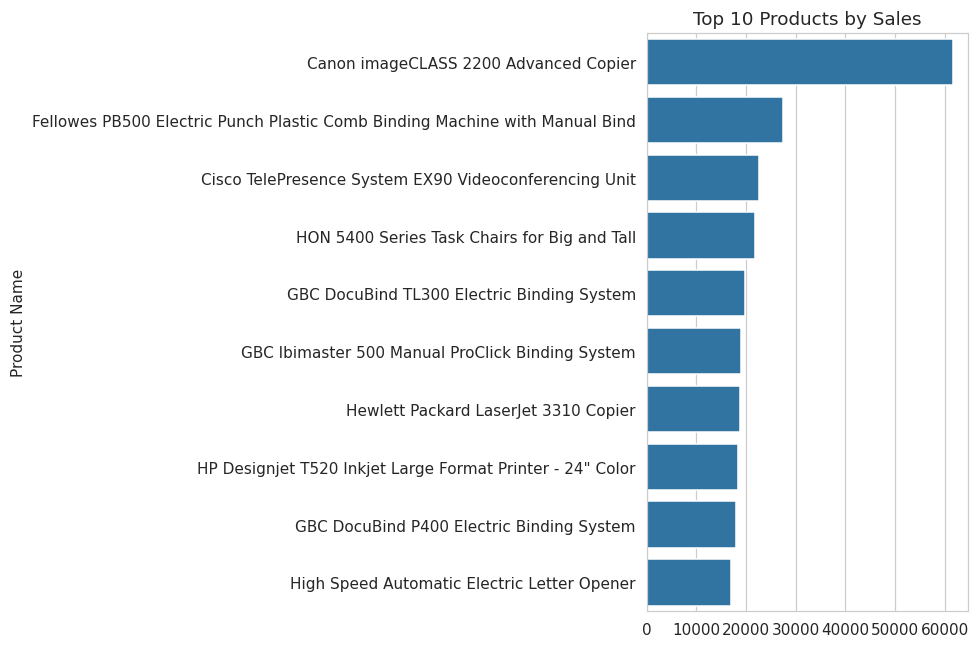

In [10]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(9,6))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Products by Sales")
plt.tight_layout()
plt.show()

## 8. Outlier Detection (IQR method)

Outlier bounds: < -272.79 or > 500.64
Number of outlier orders: 1145 (11.7%)


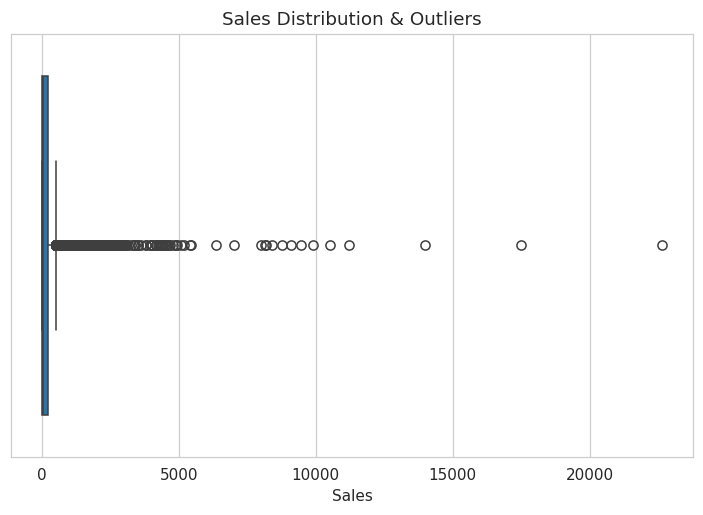

In [11]:
Q1, Q3 = df["Sales"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
outliers = df[(df["Sales"] < lower) | (df["Sales"] > upper)]
print(f"Outlier bounds: < {lower:.2f} or > {upper:.2f}")
print(f"Number of outlier orders: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

plt.figure(figsize=(8,5))
sns.boxplot(x=df["Sales"])
plt.title("Sales Distribution & Outliers")
plt.show()

## 9. Shipping Time by Ship Mode

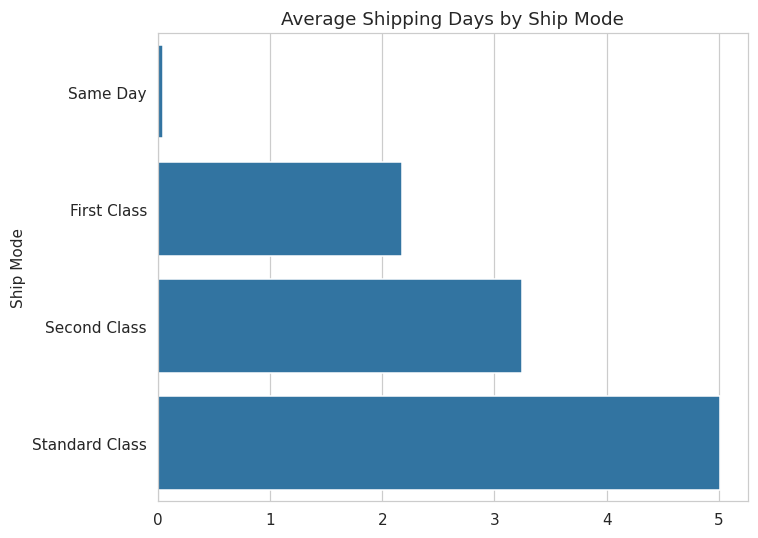

In [12]:
ship_by_mode = df.groupby("Ship Mode")["Shipping Days"].mean().sort_values()
plt.figure(figsize=(7,5))
sns.barplot(x=ship_by_mode.values, y=ship_by_mode.index)
plt.title("Average Shipping Days by Ship Mode")
plt.tight_layout()
plt.show()

## 10. Repeat Customer Analysis

In [13]:
cust_orders = df.groupby("Customer ID")["Order ID"].nunique()
repeat_rate = (cust_orders > 1).mean() * 100
print(f"Repeat customer rate: {repeat_rate:.1f}%")
print(f"Unique customers: {df['Customer ID'].nunique()}, Unique orders: {df['Order ID'].nunique()}")

Repeat customer rate: 98.4%
Unique customers: 793, Unique orders: 4922


## 11. Key Insights

1. **Total revenue (2015-2018): $2,261,536.78**
2. **Best year: 2018** ($722,052.02) — up 20.3% YoY after a dip in 2016
3. **Top region: West** ($710,219.68) — followed closely by East
4. **Top category: Technology** ($827,455.87), driven by **Phones**
5. **Consumer segment** drives ~51% of all sales
6. **Best-selling product:** Canon imageCLASS 2200 Advanced Copier
7. **98.4% of customers are repeat buyers** — strong retention
8. **11.7% of orders are statistical outliers** (large B2B-style purchases) — worth segmenting separately in pricing/discount strategy
9. **Same Day shipping** has the fastest average fulfilment time, as expected
